<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **LSTM, GRU and Transformer**


Vanilla RNNs work well when dealing with short-term dependencies but suffer from the vanishing gradient descent problem when it comes to long-term context dependencies. This is because some information is lost at each time step when traversing the layers. Gated RNNs have units that are designed to forget and to update relevant information and can provide a good solution to this problem. In this lab, we will talk about two types of gated RNNs: LSTM and GRUs.


## __Table of Contents__

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
3. [Gated RNN](#toc-gated-rnn)
    1. [LSTM](#toc-lstm)
    2. [GRU](#toc-gru)
    3. [LSTM in Keras: Time-series forecasting](#toc-lstm-in-keras-time-series-forecasting)
    4. [Exercise 1: GRU in Keras - Reuters classification](#toc-exercise-1-gru-in-keras-reuters-classification)
4. [Transformer for Text Classification](#toc-transformer-for-text-classification)
    1. [Exercise 2: Transformer Model for Text Classification](#toc-exercise-2-transformer-model-for-text-classification)


## **Objectives**<a id="toc-objectives"></a>

After completing this lab, you will be able to:

 - Explain the fundamental components of LSTM and GRU
 - Implement LSTM and GRU in Keras for various tasks and applications


----


## <a id="toc-setup"></a>**Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### <a id="toc-installing-required-libraries"></a>**Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the following code cell.


In [189]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [190]:
%%capture

#!mamba install -qy tqdm
#!pip install tensorflow --upgrade

### <a id="toc-importing-required-libraries"></a>**Importing Required Libraries**


In [191]:
# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
print(tf. __version__)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.keras.losses import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding,Masking,LSTM, GRU, Conv1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN
from tensorflow.keras.datasets import reuters
from tensorflow.keras.utils import pad_sequences


sns.set_context('notebook')
sns.set_style('white')
np.random.seed(2024)


2.20.0


## <a id="toc-gated-rnn"></a>**Gated RNN**

The two types of gated RNNs we will be studying in this lab are Long Short Term Memories (LSTM) and Gated Recurrent Units (GRU). GRU is simpler than LSTM. It's much faster and optimizes quicker. 

### <a id="toc-lstm"></a>**LSTM**

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network designed to handle long-term dependencies in sequential data. As shown in the diagram below, an LSTM keeps track of two states at each time step:

* the **cell state** $\mathbf{C}_t$, shown along the top path, which carries long-term information through the sequence,
* the **hidden state** $\mathbf{h}_t$, shown along the lower path, which carries the output information passed to the next time step.

The cell receives information from the previous time step, $\mathbf{C}_{t-1}$ and $\mathbf{h}_{t-1}$, and updates them to produce the new states $\mathbf{C}_t$ and $\mathbf{h}_t$. The key advantage of an LSTM is that it can decide what information to forget, what new information to store, and what information to output. This helps reduce the vanishing-gradient problem that standard RNNs often face.

The diagram shows three main gates that control the flow of information:

* the **forget gate** decides which parts of the previous cell state $\mathbf{C}_{t-1}$ should be kept or removed,
* the **input gate** decides which new candidate information should be added to the cell state,
* the **output gate** decides which parts of the updated cell state should be exposed as the hidden state $\mathbf{h}_t$.

These gates use sigmoid activations, which produce values between 0 and 1. A value close to 0 means the gate mostly blocks information, while a value close to 1 means the gate mostly lets information pass through. The tanh operations shown in the diagram help scale candidate values before they are added to the cell state or used to produce the hidden state.

<img src="https://wiki.math.uwaterloo.ca/statwiki/images/thumb/9/98/LSTM.png/800px-LSTM.png" alt="Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/" style="width: 500px;"> 

Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/


### <a id="toc-gru"></a>**GRU**

A Gated Recurrent Unit (GRU) is a simpler alternative to an LSTM. It is designed to capture long-term dependencies in sequential data, but it uses fewer gates and does not maintain a separate cell state. Instead, a GRU keeps a single hidden state that is updated at each time step.

A GRU uses two main gates:

* the **update gate**, which controls how much of the previous hidden state should be kept and how much new information should be added,
* the **reset gate**, which controls how much of the previous hidden state should be ignored when computing the new candidate state.

The update gate plays a role similar to the combination of the forget and input gates in an LSTM. When the model should preserve past information, the update gate keeps more of the previous hidden state. When the model should learn new information, it allows more of the candidate state to replace the old state.

Because GRUs have fewer gates and fewer parameters than LSTMs, they are often faster to train and can work well with smaller datasets. However, whether a GRU or an LSTM performs better depends on the task, the dataset, and the model configuration.

<img src="https://github.com/DataScienceUB/DeepLearningMaster2019/blob/master/images/gru.png?raw=1" alt="GRU cell diagram" style="width: 300px;"> 


### <a id="toc-lstm-in-keras-time-series-forecasting"></a>**LSTM in Keras: Time-series forecasting**


Next, we will build a simple LSTM model to solve a many-to-one time-series prediction problem on a simulated sine wave. 

In this specific example, the time index is not used for prediction, and you don't see the traditional `X_train` and `y_train` arrays because the `TimeseriesGenerator` handles that process automatically.

The following model is looking at the shape of the wave to predict the next point, so it doesn't need to know what "time" it is. It only needs to know: "The last 50 points were going up, so the next point should probably keep going up (or start turning down)."


Let's first start by generating some sine waves using the `np.sin()` function.


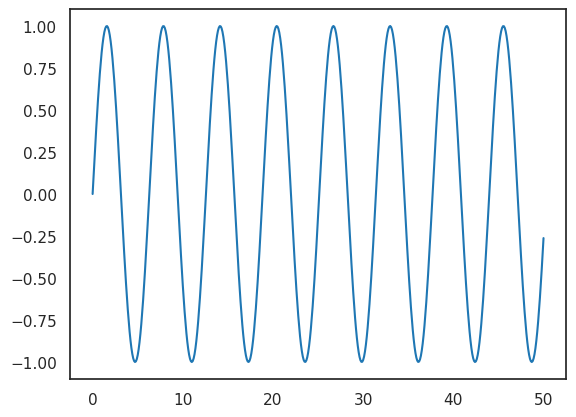

In [192]:
x = np.linspace(0, 50, 501)
y = np.sin(x)
plt.plot(x, y)

We will convert this into a data frame for convenience.


In [193]:
df = pd.DataFrame(data=y, index=x, columns=["Sine"])
df.head()

,Sine
0.0,0.000000
0.1,0.099833
0.2,0.198669
0.3,0.295520
0.4,0.389418


We are dealing with a univariate time series, so we have a total of one feature. We will be using 10% of the simulated data for testing.


In [194]:
# percentage of data used for testing
test_percent = 0.1
# number of features
n_features = 1
# sequence length
length = 50
# batch size
batch_size = 1

Let us now create a training and testing dataset to train and test our model on.


In [195]:
test_point = np.round(len(df) * test_percent)
test_ind = int(len(df) - test_point)

train = df.iloc[:test_ind]
test = df.iloc[test_ind:]

We will perform some basic preprocessing using the `MinMaxScaler`, which normalizes the input.


In [196]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

`TimeseriesGenerator` is a utility class by Keras that is used in generating batches of temporal data. Given our scaled training data, we create 401 output sequences.


In [197]:
generator = TimeseriesGenerator(
    scaled_train, scaled_train, length=length, batch_size=batch_size
)
len(generator)

401

We will use the `LSTM()` layer with 50 units, and an input shape defined by the sequence length and number of features.


In [198]:
model = Sequential()

model.add(LSTM(50, input_shape=(length, n_features)))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

In [199]:
model.fit(generator, epochs=6)

Epoch 1/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0155
Epoch 2/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4237e-04
Epoch 3/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9393e-04
Epoch 4/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.1931e-05
Epoch 5/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1457e-04
Epoch 6/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2915e-04


We will now evaluate the LSTM's performance in forecasting a few time steps from the first batch.


In [200]:
forecast = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(25):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


We will invert the min-max scaling on the predictions to allow for a direct comparison with the ground truth.


In [201]:
forecast = scaler.inverse_transform(forecast)

In [202]:
forecast_index = np.arange(50.1, 52.6, step=0.1)

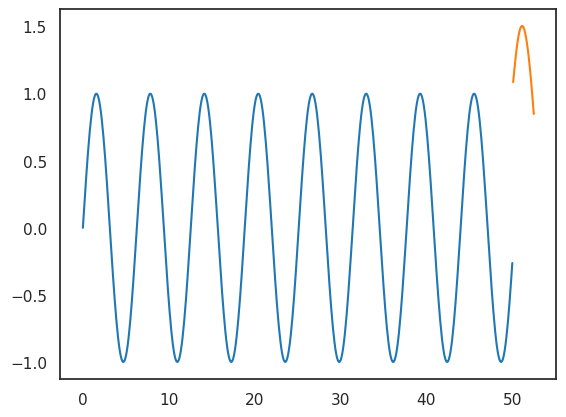

In [203]:
plt.plot(df.index, df["Sine"])
plt.plot(forecast_index, forecast)

### <a id="toc-exercise-1-gru-in-keras-reuters-classification"></a>**Exercise 1: GRU in Keras - Reuters classification**

In this exercise, you will use the reuters dataset from Keras that we imported earlier to build a classification model using GRUs.


The dataset used in this exercise is the Reuters newswire dataset from Keras. It contains 11,228 Reuters newswires labeled across 46 topics.

> Each newswire is encoded as a sequence of integer word indexes. For convenience, words are indexed according to their overall frequency in the dataset. For example, the integer `3` represents the third most frequent word. This indexing scheme makes it easy to filter the vocabulary, such as keeping only the top 10,000 most common words while excluding the top 20 most common words.

The dataset returns the following:

> `x_train`, `x_test`: lists of sequences, where each sequence is a list of integer word indexes. If the `num_words` argument is specified, the maximum possible index value is `num_words - 1`.


Let us start by defining a few hyperparameters. 

* We use 10,000 to specify `num_words`, that is, the maximum possible index value loaded is `num_words` - 1. 

* Input length of the embedding layer is specified using `maxlen`

* We will use 30% of the data for testing.


In [204]:
# Hyperparameters
num_words = 10000  # input_dim for Embedding layer
maxlen = 1000
test_split = 0.3

Next, we will use the Keras API to load in our reuters dataset.


In [205]:
# Load reuters Data from Keras datasets
(X_train, y_train), (X_test, y_test) = reuters.load_data(
    num_words=num_words, test_split=0.3
)
print(len(X_train), "train sequences")
print(len(X_test), "test sequences")

7859 train sequences
3369 test sequences


In terms of pre-processing, we pad sequences to the same length using `pad_sequences`. Sequences longer than `num_timesteps` are truncated so that they fit the desired length. Whereas sequences that are shorter than `num_timesteps` are padded with value until they are `num_timesteps` long.


In [206]:
# data preprocessing
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train

X_train shape: (7859, 1000)
X_test shape: (3369, 1000)


array([[   0,    0,    0, ...,   15,   17,   12],
       [   0,    0,    0, ...,  505,   17,   12],
       [   0,    0,    0, ...,   11,   17,   12],
       ...,
       [   0,    0,    0, ...,  889,   17,   12],
       [   0,    0,    0, ..., 4416,   17,   12],
       [   0,    0,    0, ...,   48,   17,   12]], dtype=int32)

In [207]:
y_train = tf.keras.utils.to_categorical(y_train, 46)
y_test = tf.keras.utils.to_categorical(y_test, 46)

Start by defining the model architecture. Use a `GRU` layer with 128 units, and a dropout rate of 0.2. Use a dense layer with 46 units and softmax as the activation function. Print out the model summary.


In [ ]:
# Write your solution here
model = Sequential()
model.add(Embedding(input_dim=num_words, output_dim=300, input_length=1000))
model.add(GRU(128, dropout=0.2))
model.add(Dense(46, activation="softmax"))

Now compile the model using categorical_crossentropy as the loss function, adam as the optimizer and accuracy as the metric. Train the model using 256 as the batch size, over 10 training iterations and using 20% of the data for validation purposes. Finally, evaluate the model's performance on the test dataset.


In [ ]:
# Write your solution here
model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)
history_gru = model.fit(
    X_train, y_train, batch_size=256, epochs=10, validation_split=0.2
)
model.summary()

Epoch 1/10


25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 817ms/step - accuracy: 0.3157 - loss: 2.9121 - val_accuracy: 0.4402 - val_loss: 2.2620
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 815ms/step - accuracy: 0.4326 - loss: 2.1192 - val_accuracy: 0.4835 - val_loss: 1.9697
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 812ms/step - accuracy: 0.4834 - loss: 1.8986 - val_accuracy: 0.5178 - val_loss: 1.8620
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 809ms/step - accuracy: 0.5357 - loss: 1.7235 - val_accuracy: 0.5617 - val_loss: 1.7190
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 807ms/step - accuracy: 0.5866 - loss: 1.5882 - val_accuracy: 0.5833 - val_loss: 1.6619
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 804ms/step - accuracy: 0.6170 - loss: 1.4907 - val_accuracy: 0.5961 - val_loss: 1.6766
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 797ms/step - accuracy: 0.6381 - loss: 1.4242 - val_accuracy: 0.5719 - val_loss: 1.7165
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 800ms/step - accuracy: 0.6687 - loss: 1.3389 - val_accuracy: 0.596

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_24 (Embedding)        │ (None, 1000, 300)      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 128)            │       165,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,513,164 (36.29 MB)

 Trainable params: 3,171,054 (12.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,342,110 (24.19 MB)

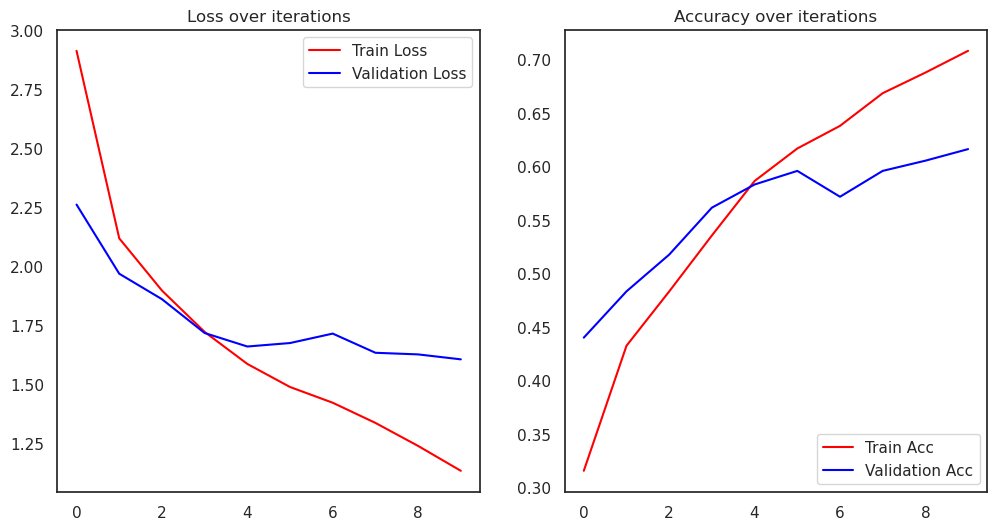

In [ ]:
def display_metrics(history):

    n = len(history.history["loss"])

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(range(n), (history.history["loss"]), "r", label="Train Loss")
    ax.plot(
        range(n), (history.history["val_loss"]), "b", label="Validation Loss"
    )
    ax.legend()
    ax.set_title("Loss over iterations")

    ax = fig.add_subplot(1, 2, 2)
    ax.plot(range(n), (history.history["accuracy"]), "r", label="Train Acc")
    ax.plot(
        range(n), (history.history["val_accuracy"]), "b", label="Validation Acc"
    )
    ax.legend(loc="lower right")
    ax.set_title("Accuracy over iterations")


display_metrics(history_gru)

## <a id="toc-transformer-for-text-classification"></a>**Transformer for Text Classification**

Transformers are neural network architectures that model relationships between tokens using **self-attention**. Unlike RNNs, LSTMs, and GRUs, a Transformer does not read a sentence one token at a time. It can compare all tokens in the sequence in parallel.

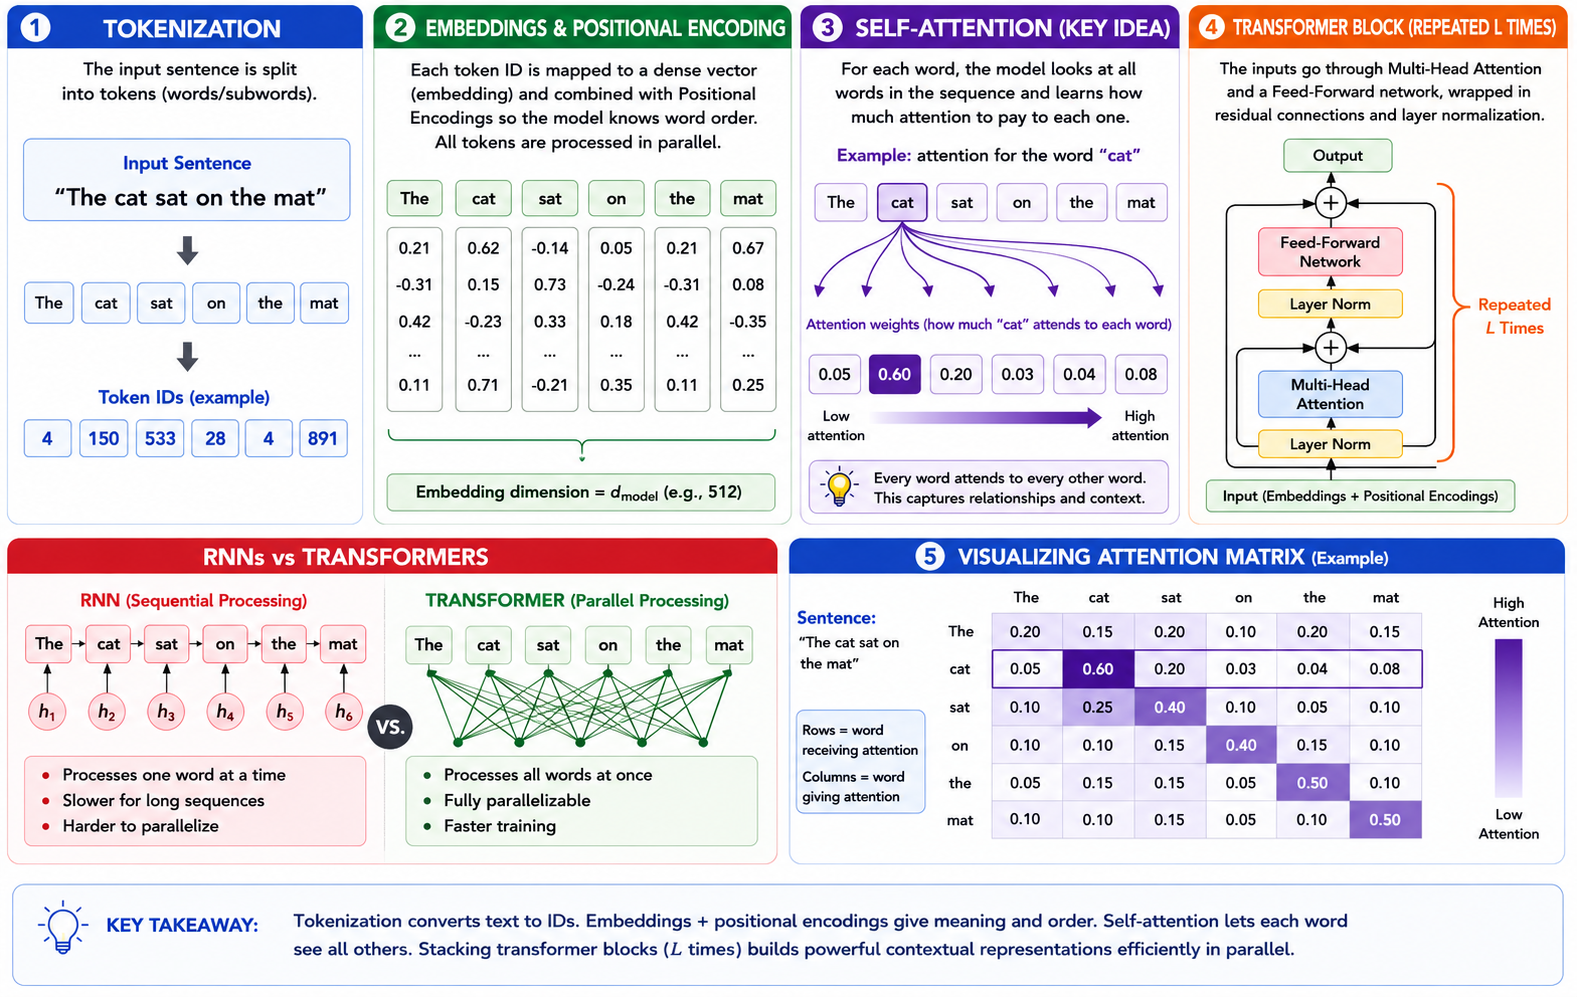

The image above shows the main Transformer workflow for text. First, the sentence is split into tokens and converted into token IDs. Then each token ID is mapped to an embedding vector. Because the Transformer processes all tokens at once, positional encoding is added so the model knows the order of the tokens.

Next, self-attention lets each token look at every other token and decide which words are most relevant. For example, the word `cat` may pay more attention to nearby or related words in the sentence. A Transformer block then applies multi-head attention, layer normalization, residual connections, and a feed-forward network. Stacking several Transformer blocks builds richer contextual representations. For classification, the sequence representation is pooled or summarized and passed to a final dense classifier.

A typical text classification workflow is:

```text
token IDs
-> token embedding
-> add position embedding
-> self-attention
-> feed-forward dense block
-> pooling
-> final dense classifier
```

1. **Embedding and Positional Encoding:** Tokens are first converted into dense vectors called embeddings. Since Transformers do not naturally know token order, positional embeddings are added to the token embeddings. This gives the model both word meaning and word position.

2. **Attention Mechanism:** Self-attention measures how strongly each token should use information from other tokens. It creates three learned projections from the token representations: **Query (Q)**, **Key (K)**, and **Value (V)**.

    The attention output is calculated as follows:

    $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

    **Query (Q)**, **Key (K)**, and **Value (V)** are not labels from the dataset. They are learned linear projections of the token embeddings, created using weight matrices ($W_Q, W_K, W_V$):
    - **Query:** Represents what the current token is looking for.
    - **Key:** Represents what each token offers for matching.
    - **Value:** Represents the information each token contributes.

    The model compares each Query with all Keys using dot products. These scores are scaled by $\sqrt{d_k}$ and passed through softmax to become attention weights. The weights are then used to combine the Value vectors. This lets the model emphasize useful context and reduce less useful information.

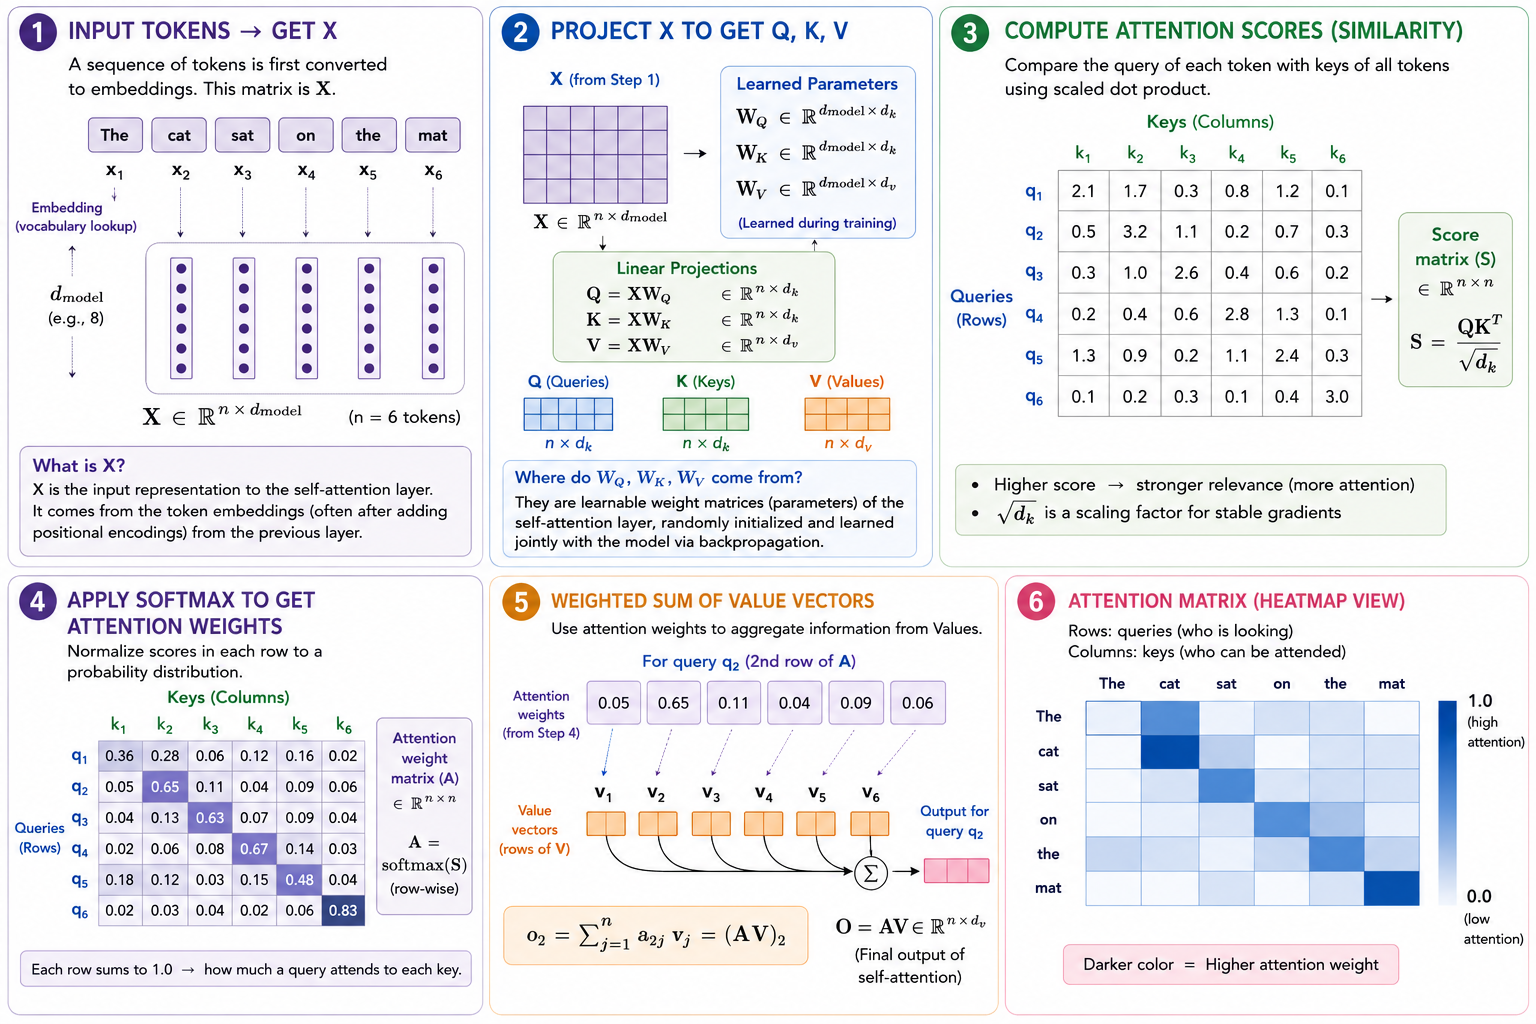

The above image explains the attention calculation in more detail. Token embeddings form the input matrix $X$. The model projects $X$ into $Q$, $K$, and $V$, computes attention scores with $QK^T$, normalizes them with softmax, and uses the attention weights to create a weighted sum of the Value vectors. The heatmap shows the attention matrix: darker cells mean stronger attention between two tokens.

3. **Feed-Forward Network:** After attention, residual connections and layer normalization help stabilize training. A feed-forward dense block then refines each token representation.

Finally, pooling converts the sequence of token representations into a single vector for the whole document. The final dense layer uses this document-level vector to predict the class label.


The image below shows a common Keras workflow for building a Transformer text classifier. First, define an input layer for token IDs. Next, use an embedding layer to convert token IDs into dense vectors, then add positional encoding so the model knows token order. The data then passes through one or more Transformer blocks. Each block contains multi-head attention, a feed-forward network, layer normalization, and residual connections.

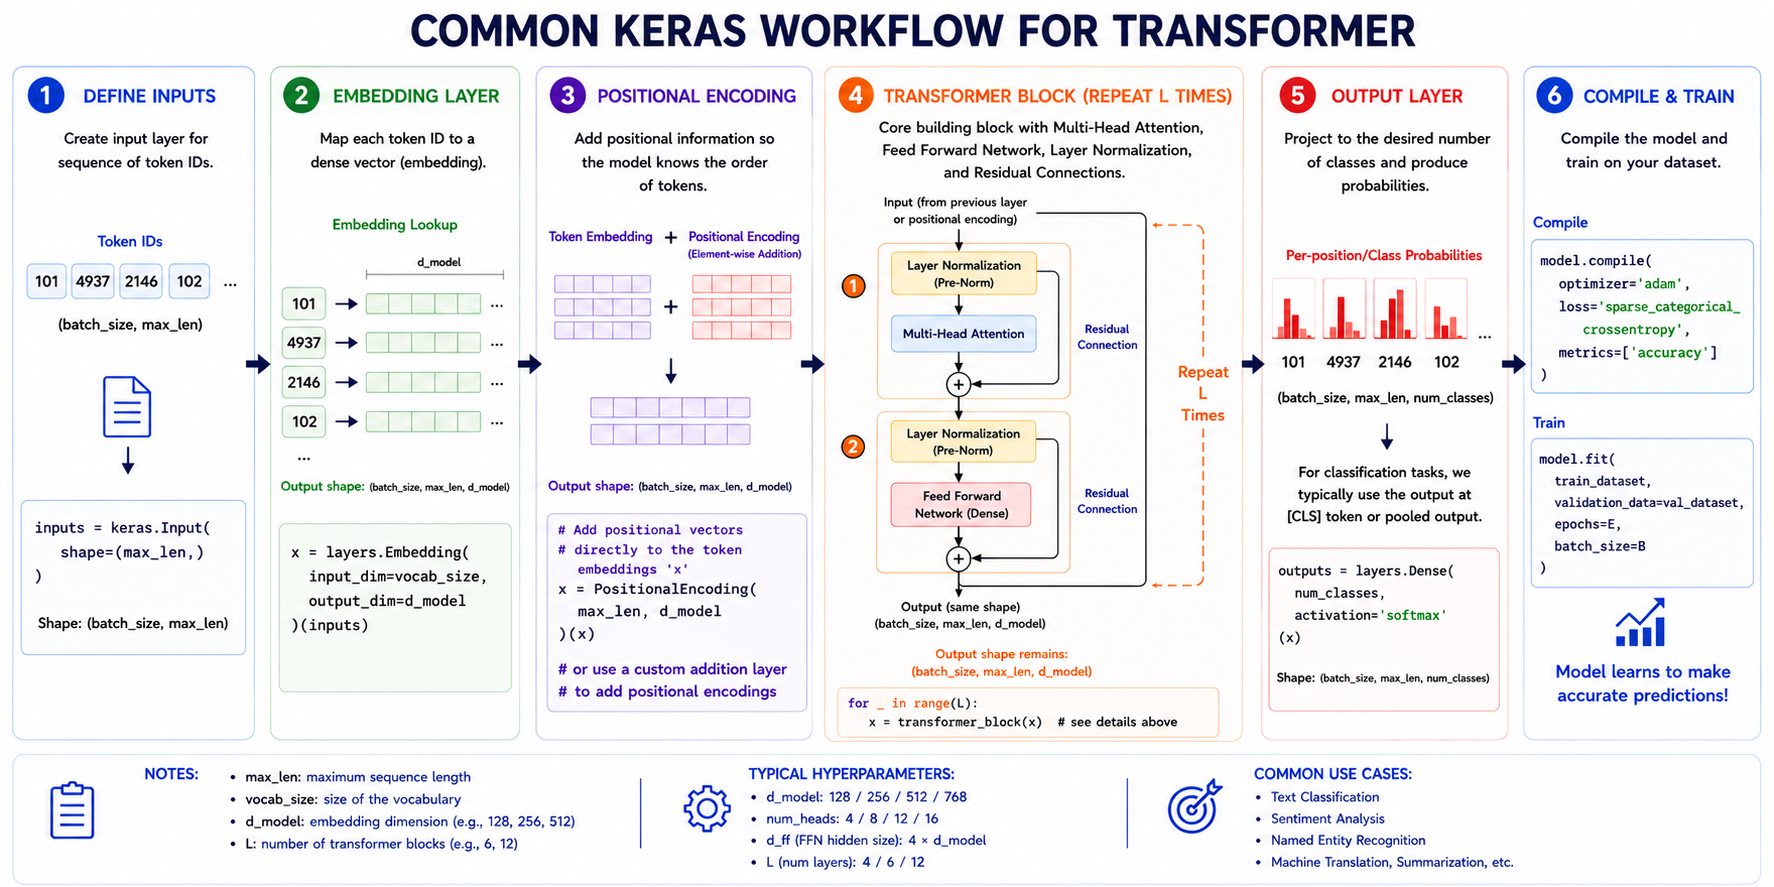

For text classification, the model uses a pooled sequence output or a special classification token representation. A final dense layer converts this representation into class probabilities. The model is then compiled with an optimizer, loss function, and metric, and trained on the dataset.


In this lab, the Transformer model is included as a comparison with GRU. A small Transformer trained from scratch may not always outperform a GRU on a small dataset such as Reuters. However, it helps illustrate the main idea behind modern attention-based text models: each token can directly use information from all other tokens in the sequence.


### <a id="toc-exercise-2-transformer-model-for-text-classification"></a>**Exercise 2: Transformer Model for Text Classification**

In this exercise, you will use the Reuters dataset from Keras to build a text classification model with a small Transformer-based architecture. This model provides a comparison with the GRU model from Exercise 1.

Following the workflow shown above, you will use token embeddings, positional embeddings, self-attention, pooling, and a final dense classifier to predict one of the 46 Reuters topic classes.


In [ ]:
from tensorflow.keras import layers, Model

maxlen = 1000
num_words = 10000
embed_dim = 128
num_heads = 4  # Number of attention heads
ff_dim = 128  # Dimension of the "feed forward" network inside the transformer
num_classes = 46

In [ ]:
inputs = layers.Input(shape=(maxlen,))

# Token embedding
x = layers.Embedding(input_dim=num_words, output_dim=embed_dim)(inputs)

# Position embedding
positions = tf.range(start=0, limit=maxlen, delta=1)
position_embedding = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)(
    positions
)
x = x + position_embedding

# Self-attention learns relationships between tokens
attention_output = layers.MultiHeadAttention(
    num_heads=num_heads, key_dim=embed_dim
)(x, x)

# Residual connection + normalization
# Residual connection does not replace the old information completely.
# It keeps the old information, and add the new learned information on top.
attention_layer = layers.LayerNormalization()(x + attention_output)

# Feed-forward layer
# transforms/refines each token representation
feed_forward_layer_1 = layers.Dense(ff_dim, activation="relu")(attention_layer)
feed_forward_layer_2 = layers.Dense(embed_dim)(feed_forward_layer_1)

# Residual connection + normalization
normalization_layer = layers.LayerNormalization()(
    attention_layer + feed_forward_layer_2
)

# Classification head
pooling_layer = layers.GlobalAveragePooling1D()(normalization_layer)
dense_layer = layers.Dense(128, activation="relu")(pooling_layer)
dropout_layer_2 = layers.Dropout(0.2)(dense_layer)

outputs = layers.Dense(num_classes, activation="softmax")(dropout_layer_2)

model = Model(inputs, outputs)

In [213]:
model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_25        │ (None, 1000, 128) │  1,280,000 │ input_layer_23[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 1000, 128) │          0 │ embedding_25[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1000, 128) │    263,808 │ add_24[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_24[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 1000, 128) │          0 │ add_24[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1000, 128) │        256 │ add_25[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 1000, 128) │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 1000, 128) │     16,512 │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_26 (Add)        │ (None, 1000, 128) │          0 │ layer_normalizat… │
│                     │                   │            │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1000, 128) │        256 │ add_26[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 128)       │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 46)        │      5,934 │ dropout_23[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,599,790 (6.10 MB)

 Trainable params: 1,599,790 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


25/25 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.3148 - loss: 2.6378 - val_accuracy: 0.3581 - val_loss: 2.3531
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.3541 - loss: 2.4290 - val_accuracy: 0.3620 - val_loss: 2.2957
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.3627 - loss: 2.3861 - val_accuracy: 0.3721 - val_loss: 2.2418
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.3840 - loss: 2.2816 - val_accuracy: 0.3995 - val_loss: 2.1186
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.4746 - loss: 2.0293 - val_accuracy: 0.5757 - val_loss: 1.6970
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.6130 - loss: 1.6359 - val_accuracy: 0.6501 - val_loss: 1.4536
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.6739 - loss: 1.4086 - val_accuracy: 0.6737 - val_loss: 1.3274
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.7034 - loss: 1.2514 - val_accuracy: 0.7004 - val_loss: 1.2097
Epo

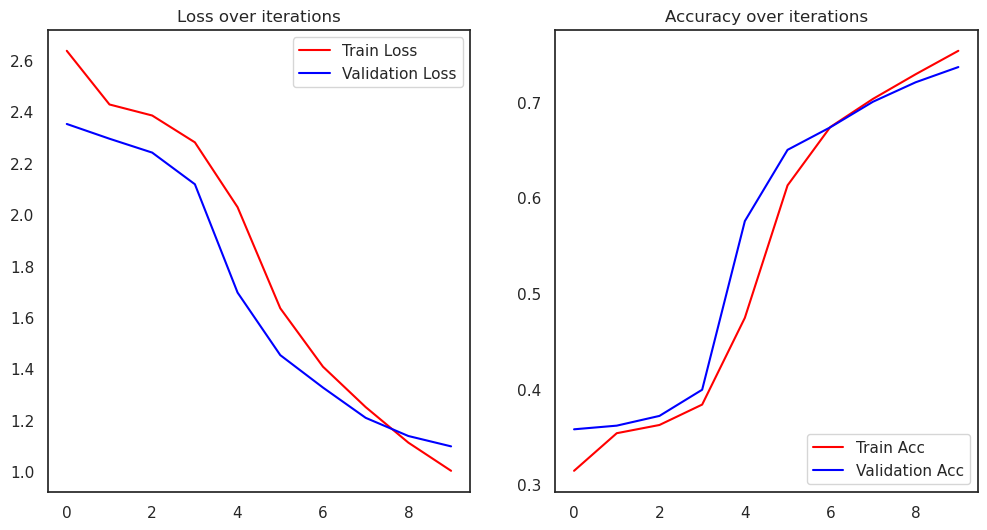

In [ ]:
model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

history_transformer = model.fit(
    X_train, y_train, batch_size=256, epochs=10, validation_split=0.2
)

display_metrics(history_transformer)

## **Authors**


[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01)


Kopal is a Masters student in Computer Science at the University of Toronto.

Su Wu

## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2022-06-23|0.1|Kopal|Create Lab|
|2022-09-08|0.1|Steve Hord|QA pass edits|
| 2026-05-27     | 0.2     | Su Wu| Documentation and script edits    |


Copyright © 2022 IBM Corporation. All rights reserved.
